# MNIST VAE (2025)

- Implemented a Variational Autoencoder (VAE) in PyTorch with a convolutional encoder and decoder for MNIST image generation
- Implemented the reparameterization trick, Gaussian log-likelihood, and KL divergence to construct the ELBO training objective
- Trained the VAE using GPU acceleration and evaluated reconstruction quality through ELBO training curves
- Generated new MNIST samples by sampling from the latent prior and decoding the resulting latent representations

## Setup

In [1]:
# Imports
import torch
import random
import tarfile, requests, os

import numpy as np
import matplotlib.pylab as plt

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms

from tqdm.notebook import tqdm, trange

In [2]:
def set_seed(seed=2025, mute=True):
  """
  Seet randomseed to control randomness.
  """
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.cuda.manual_seed(seed)
  torch.backends.cudnn.benchmark = False
  torch.backends.cudnn.deterministic = True

  if not mute:
    print(f'Random seed {seed} has been set.')

def set_device():
  """
  Set the device on which to run PyTorch. CUDA if available, CPU otherwise
  """
  device = "cuda" if torch.cuda.is_available() else "cpu"
  if device != "cuda":
    print("WARNING: For this notebook to perform best, please enable GPU.")
  else:
    print("GPU is enabled in this notebook.")

  return device

In [3]:
SEED=2025
set_seed(seed=SEED, mute=False)
DEVICE = set_device()

Random seed 2025 has been set.
GPU is enabled in this notebook.


In [5]:
# Download MNIST dataset
fname = 'MNIST.tar.gz'
name = 'mnist'
url = 'https://osf.io/y2fj6/download'

if not os.path.exists(name):
  print('\nDownloading MNIST dataset...')
  r = requests.get(url, allow_redirects=True)
  with open(fname, 'wb') as fh:
    fh.write(r.content)
  print('\nDownloading MNIST completed!\n')

if not os.path.exists(name):
  with tarfile.open(fname) as tar:
    tar.extractall(name)
    os.remove(fname)
else:
  print('MNIST dataset has been downloaded.\n')

# Load MNIST image datasets
# See https://pytorch.org/docs/stable/torchvision/datasets.html
train_set = datasets.MNIST('./mnist/',
                       train=True,
                       transform=transforms.ToTensor(),
                       download=False)
data_shape = (1, 28, 28)
data_size = 28 * 28

MNIST dataset has been downloaded.



In [7]:
def plot_torch_image(image, ax=None):
  """
  Helper function to plot torch image
  @param image: torch.Tensor
  @param ax: plt object
  """
  ax = ax if ax is not None else plt.gca()
  c, h, w = image.size()
  if c==1:
    cm = 'gray'
  else:
    cm = None

  # [C, H, W] -> [H, W, C]
  im_plt = torch.clip(image.detach().cpu().permute(1,2,0).squeeze(), 0.0, 1.0)
  ax.imshow(im_plt, cmap=cm)
  ax.set_xticks([])
  ax.set_yticks([])
  ax.spines['right'].set_visible(False)
  ax.spines['top'].set_visible(False)


def plot_images(images, h=3, w=3, plt_title=''):
  """
  Helper function to plot images.
  @param images: torch.Tensor
  @param h: int, number of images in height direction
  @param w: int, number of images in width direction
  @param plt_title: string, Plot title
  """
  plt.figure(figsize=(h*2, w*2))
  plt.suptitle(plt_title)
  for i in range(h*w):
    plt.subplot(h, w, i + 1)
    plot_torch_image(images[i])

  plt.axis('off')
  plt.show()



In [118]:
def log_prob(x: torch.Tensor, mu: torch.Tensor, log_sigma: torch.Tensor) -> torch.Tensor:
  """
  ### Fill in this function ###
  Compute element-wise log Gaussian probability.
  @param x:          [B, N, K]: input data (observations of Gaussian distribution), there are N samples for each of the B batches, each sample has K dimensions.
  @param mu:         [B, N, K]: mean of Gaussian distribution.
  @param log_sigma:  [B, N]: log of standard deviation of Gaussian distribution.
  @return log_prob:  [B, N]: log Gaussian probability for each sample in the batch.
  """
  ### START CODE HERE ###

  # PI
  pi_tensor = torch.tensor(np.pi) 

  pi_sigma_const= -0.5 * torch.log( 2 * pi_tensor )
  # [B N 1] (sigma = std_dev)
  std_dev = torch.exp(log_sigma.unsqueeze(-1)) 
  x_norm = (x - mu) / std_dev
  # Element wise sigma for x-mu square
  x_norm_square = -0.5*torch.pow(x_norm,2) 
  log_sigma = -1*log_sigma.unsqueeze(-1)

  # Add them up for p(x|u,sigma^2 I)
  log_prob = pi_sigma_const + x_norm_square + log_sigma
  # Return
  log_prob = log_prob.sum(dim=-1)


  ### END CODE HERE ###
  return log_prob


def gt_log_prob(x: torch.Tensor, mu: torch.Tensor, log_sigma: torch.Tensor) -> torch.Tensor:
  """
  Ground truth function used for unit test. Do not modify.
  @param x:          [B, N, K]: input data (observations of Gaussian distribution), there are N samples for each of the B batches, each sample has K dimensions.
  @param mu:         [B, N, K]: mean of Gaussian distribution.
  @param log_sigma:  [B, N]: log of standard deviation of Gaussian distribution.
  @return log_prob:  [B, N]: log Gaussian probability for each sample in the batch.
  """
  gt_log_prob = torch.distributions.normal.Normal(mu, log_sigma[:, :, None].exp()).log_prob(x)
  gt_log_prob = gt_log_prob.sum(dim=-1)
  return gt_log_prob


def unit_test_log_prob(func_log_prob=log_prob, func_gt_log_prob=gt_log_prob):
  """
  Unit test helper. Do not modify.
  """
  b, n = torch.randint(1, 32, [2])
  k = torch.randint(1, 8, [1])
  x = torch.randn([b, n, k])
  mu = torch.randn([b, n, k])
  log_sigma = torch.rand([b, n])

  true_log_prob = func_gt_log_prob(x, mu, log_sigma)                  # [B, N]
  compute_log_prob = func_log_prob(x, mu, log_sigma)                  # [B, N]
  error = (true_log_prob - compute_log_prob).square().mean().sqrt()   # scalar

  if error < 1e-5:
    print("Your implementation is correct.")
  else:
    print("Your implementation is incorrect.")


set_seed(seed=SEED)
unit_test_log_prob()

Your implementation is correct.


In [124]:
def kl_q_p_mc(samples_q: torch.Tensor, params_q: torch.Tensor, params_p: torch.Tensor) -> torch.Tensor:
  """
  ### Fill in this function ###
  Compute the KL divergence between the q distirubtion and p distribution using Monte-Carlo approximation.
  Hints: you could reuse the above log_prob function.
  @param samples_q: [B, N, K]: samples from B many q distributions, there are N samples in each batch, each of them has K dimensions
  @param params_q: [B, K+1]: parameters of B many q distribution, the first K elements are the mean, the last element is the log standard deviation
  @param params_p: [B, K+1]: parameters of B many p distribution, the first K elements are the mean, the last element is the log standard deviation
  @return kl_q_p_mc [B]: KL(q||p) for q||p
  """
  # Init
  b, n, k = samples_q.size()
  mu_q, log_sig_q = params_q[:, :-1], params_q[:, -1]  # [B, K], [B]
  mu_p, log_sig_p = params_p[:, :-1], params_p[:, -1]  # [B, K], [B]

  ### START CODE HERE ###


  # log q(x)
  log_qxi = log_prob(samples_q, mu_q.unsqueeze(1), log_sig_q.unsqueeze(1))
  # log p(x)
  log_pxi = log_prob(samples_q, mu_p.unsqueeze(1), log_sig_p.unsqueeze(1))
  # Return KL(q||p)
  kl_mc = torch.mean(log_qxi - log_pxi,1)


  ### END CODE HERE ###
  return kl_mc


def gt_kl_q_p_mc(samples_q: torch.Tensor, params_q: torch.Tensor, params_p: torch.Tensor) -> torch.Tensor:
  """
  Ground truth function used for unit test. Do not modify.
  @param samples_q: [B, N, K]: samples from B many q distributions, there are N samples in each batch, each of them has K dimensions
  @param params_q: [B, K+1]: parameters of B many q distribution, the first K elements are the mean, the last element is the log standard deviation
  @param params_p: [B, K+1]: parameters of B many p distribution, the first K elements are the mean, the last element is the log standard deviation
  @return kl_q_p_mc [B]: KL(q||p) for q||p
  """
  # Init
  b, n, k = samples_q.size()
  mu_q, log_sig_q = params_q[:, :-1], params_q[:, -1]  # [B, K], [B]
  mu_p, log_sig_p = params_p[:, :-1], params_p[:, -1]  # [B, K], [B]
  sigma_q, sigma_p = log_sig_q.exp(), log_sig_p.exp()  # [B], [B]

  gt_log_prob_q = torch.distributions.normal.Normal(mu_q.unsqueeze(1), sigma_q[:, None, None]).log_prob(samples_q)  # [B, N, K]
  gt_log_prob_q = gt_log_prob_q.sum(dim=-1)  # [B]
  gt_log_prob_p = torch.distributions.normal.Normal(mu_p.unsqueeze(1), sigma_p[:, None, None]).log_prob(samples_q)  # [B, N, K]
  gt_log_prob_p = gt_log_prob_p.sum(dim=-1)  # [B]
  return (gt_log_prob_q - gt_log_prob_p).mean(dim=1)  # [B]


def unit_test_kl_q_p_mc(func_kl_q_p_mc=kl_q_p_mc, func_gt_kl_q_p_mc=gt_kl_q_p_mc):
  """
  Unit test helper. Do not modify.
  """
  b, n = torch.randint(1, 32, [2])
  k = torch.randint(1, 8, [1])
  x_q = torch.randn([b, n, k])
  mu_q = torch.randn([b, k])
  log_sigma_q = torch.rand([b])

  mu_p = torch.randn([b, k])
  log_sigma_p = torch.rand([b])

  params_q = torch.cat([mu_q, log_sigma_q[:, None]], dim=-1)            # K means + 1 log sigma
  params_p = torch.cat([mu_p, log_sigma_p[:, None]], dim=-1)            # K means + 1 log sigma

  true_kl_q_p_mc =  func_gt_kl_q_p_mc(x_q, params_q, params_p)     # [B]
  compute_kl_q_p_mc = func_kl_q_p_mc(x_q, params_q, params_p)      # [B]
  error = (true_kl_q_p_mc - compute_kl_q_p_mc).square().mean().sqrt()   # scalar
  if error < 1e-5:
    print("Your implementation is correct.")
  else:
    print("Your implementation is incorrect.")


set_seed(seed=SEED)
unit_test_kl_q_p_mc()

Your implementation is correct.


In [128]:
def kl_q_p_exact(params_q: torch.Tensor, params_p: torch.Tensor) -> torch.Tensor:
  """
  ### Fill in this function ###
  Compute the exact KL divergence between the q distirubtion and p distribution.
  Hints: you could reuse the above log_prob function.
  @param params_q: [B, K+1]: parameters of B many q distribution, the first K elements are the mean, the last element is the log standard deviation
  @param params_p: [B, K+1]: parameters of B many p distribution, the first K elements are the mean, the last element is the log standard deviation
  @return kl_q_p_e [B]: KL(q||p) for q||p
  """
  # Init
  b, k_ = params_q.shape
  k = k_ - 1
  mu_q, log_sig_q = params_q[:, :-1], params_q[:, -1]  # [B, K], [B]
  mu_p, log_sig_p = params_p[:, :-1], params_p[:, -1]  # [B, K], [B]

  ### START CODE HERE ###


  # std dev (sigma) size [B]
  sigma_q = torch.exp(log_sig_q)  
  sigma_p = torch.exp(log_sig_p)  

  # var (k * sigma^2)
  k_var = k * torch.pow((sigma_q / sigma_p),2)

  # mu size [B x K]
  mu_diff = mu_q - mu_p  
  mu_qp = torch.sum(torch.pow(mu_diff,2), dim=1) / torch.pow(sigma_p,2)

  # Log determinant term: 2k * log 
  twok_log = 2*k*(log_sig_p - log_sig_q)

  # Combine terms into the final KL divergence
  kl = 0.5 * (k_var + mu_qp - k + twok_log)



  ### END CODE HERE ###

  return kl


def gt_kl_q_p_exact(params_q: torch.Tensor, params_p: torch.Tensor) -> torch.Tensor:
  """
  Ground truth function used for unit test. Do not modify.
  @param params_q: [B, K+1]: parameters of B many q distribution, the first K elements are the mean, the last element is the log standard deviation
  @param params_p: [B, K+1]: parameters of B many p distribution, the first K elements are the mean, the last element is the log standard deviation
  @return kl_q_p_e [B]: KL(q||p) for q||p
  """
  # Init
  mu_q, log_sig_q = params_q[:, :-1], params_q[:, -1]  # [B, K], [B]
  mu_p, log_sig_p = params_p[:, :-1], params_p[:, -1]  # [B, K], [B]

  gt_log_prob_q = torch.distributions.normal.Normal(mu_q, log_sig_q[:, None].exp())
  gt_log_prob_p = torch.distributions.normal.Normal(mu_p, log_sig_p[:, None].exp())
  gt_kl_q_p_exact = torch.distributions.kl.kl_divergence(gt_log_prob_q, gt_log_prob_p).sum(dim=-1)  # [B] <- [B, K]
  return gt_kl_q_p_exact  # [B]


def unit_test_kl_q_p_exact(func_kl_q_p_exact=kl_q_p_exact, func_gt_kl_q_p_exact=gt_kl_q_p_exact):
  """
  Unit test helper. Do not modify.
  """
  b = torch.randint(1, 32, [1])
  k = torch.randint(1, 8, [1])
  mu_q = torch.randn([b, k])
  log_sigma_q = torch.rand([b])
  mu_p = torch.randn([b, k])
  log_sigma_p = torch.rand([b])

  params_q = torch.cat([mu_q, log_sigma_q[:, None]], dim=-1)
  params_p = torch.cat([mu_p, log_sigma_p[:, None]], dim=-1)

  compute_kl_q_p_exact = func_kl_q_p_exact(params_q, params_p)  # [B]
  true_kl_q_p_exact = func_gt_kl_q_p_exact(params_q, params_p)  # [B]

  error = (true_kl_q_p_exact - compute_kl_q_p_exact).square().mean().sqrt()  # scalar
  if error < 1e-5:
    print("Your implementation is correct.")
  else:
    print("Your implementation is incorrect.")


set_seed(seed=SEED)
unit_test_kl_q_p_exact()

Your implementation is correct.


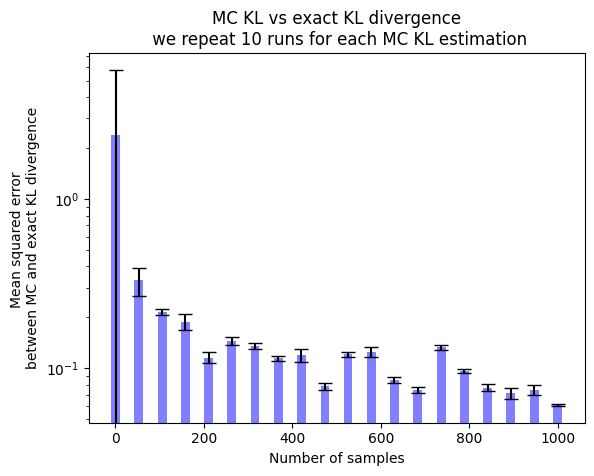

In [131]:
def compare_exact_mc_kl(func_gt_kl_q_p_exact=gt_kl_q_p_exact, func_gt_kl_q_p_mc=gt_kl_q_p_mc):
    """
    Unit test helper. Do not modify.
    """
    b, k = 1, 4
    mu_q = torch.zeros([b, k])
    log_sigma_q = torch.zeros([b])
    mu_p = torch.ones([b, k]) * 10.0
    log_sigma_p = torch.ones([b])

    params_q = torch.cat([mu_q, log_sigma_q[:, None]], dim=-1)
    params_p = torch.cat([mu_p, log_sigma_p[:, None]], dim=-1)

    true_kl_q_p_exact = func_gt_kl_q_p_exact(params_q, params_p)  # [B]

    num_samples = torch.linspace(1, 1000, 20).clamp(min=1.0).long()
    num_repeat = 10

    diff_ls, var_ls = [], []
    for n in num_samples:
        this_diff = []
        for r in range(num_repeat):
            x_q = torch.distributions.normal.Normal(mu_q, log_sigma_q[:, None].exp()).sample([n])  # [N, B, K]
            x_q = x_q.permute(1, 0, 2)  # [B, N, K]
            true_gt_kl_q_p_mc = func_gt_kl_q_p_mc(x_q, params_q, params_p)  # [B]

            this_diff.append((true_kl_q_p_exact - true_gt_kl_q_p_mc).norm(p=2).item())  # scalar

        diff_ls.append(np.mean(this_diff))  # scalar
        var_ls.append(np.var(this_diff))  # scalar

    fig = plt.figure()
    ax = fig.gca()
    # ax.scatter(num_samples.numpy(), diff_ls)
    ax.bar(num_samples.numpy(), diff_ls, width=20.0, yerr=var_ls, capsize=5.0, color='blue', alpha=0.5)
    ax.set_xlabel("Number of samples")
    ax.set_ylabel("Mean squared error \nbetween MC and exact KL divergence")
    # ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title("MC KL vs exact KL divergence\n we repeat 10 runs for each MC KL estimation")

    # print(diff_ls)

    plt.show()

set_seed(seed=SEED)
compare_exact_mc_kl()


Your implementation is likely correct.


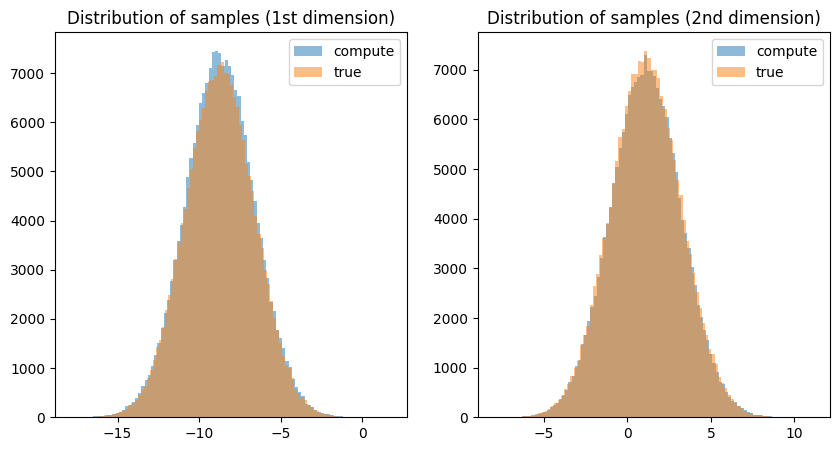

In [135]:
def rsample(params_q: torch.Tensor, num_samples: int) -> torch.Tensor:
    """
    ### Fill in this function ###
    Obtain samples from Gaussian distributions, provided the mean and covariance parameters.
    @param params_q:        [B, K+1]: parameters of B many q distribution, the first K elements are the mean, the last element is the log standard deviation
    @param num_samples:     int: number of samples to create
    @return x_q:            [B, N, K]: samples from q distribution, where N is the number of samples
    """

    # Init
    b, k_ = params_q.shape
    k = k_ - 1
    mu_q, log_sig_q = params_q[:, :-1], params_q[:, -1]  # [B, K], [B]

    ### START CODE HERE ###

    
    # NOTE THE DEVICE STUFF, without it 2.1 WILL GIVE ERROR
    # Have to move all onto same CUDA device (params_q)
    device = params_q.device 

    z = torch.randn(b, num_samples, k, device=device)
    sigma = torch.exp(log_sig_q).unsqueeze(1).to(device)

    # x = mu + sigma*z
    mu = mu_q.unsqueeze(1).to(device) 
    sigma_z =sigma.unsqueeze(2) * z
    #return 
    x_q =  mu + sigma_z
    

    ### END CODE HERE ###

    return x_q


def gt_rsample(params_q: torch.Tensor, num_samples: int) -> torch.Tensor:
    """
    Ground truth implementation of rsample. Do not modify.
    @param params_q:        [B, K+1]: parameters of B many q distribution, the first K elements are the mean, the last element is the log standard deviation
    @param num_samples:     int: number of samples to create
    @return x_q:            [B, N, K]: samples from q distribution, where N is the number of samples
    """
    # Init
    b, k_ = params_q.shape
    k = k_ - 1
    mu_q, log_sig_q = params_q[:, :-1], params_q[:, -1]  # [B, K], [B]

    x_q = torch.distributions.normal.Normal(mu_q, log_sig_q[:, None].exp()).sample([num_samples])  # [N, B, K]
    x_q = x_q.permute(1, 0, 2)  # [B, N, K]
    return x_q


def unit_test_rsample(func_rsample=rsample, func_gt_rsample=gt_rsample):
    """
    Unit test helper. Do not modify.
    """
    b, k = 1, 2
    mu_q = torch.randn([b, k]) * 10.0
    log_sigma_q = torch.rand([b])

    params_q = torch.cat([mu_q, log_sigma_q[:, None]], dim=-1)

    num_samples = 200000 # CHANGED ACCORDING TO https://piazza.com/class/m5lcfy9klal5kc/post/151

    compute_x_q = func_rsample(params_q, num_samples)            # [B, N, K]
    true_x_q = func_gt_rsample(params_q, num_samples)            # [B, N, K]

    mean_error = (compute_x_q.mean(dim=1) - true_x_q.mean(dim=1)).mean(dim=-1)  # [B]
    std_error = (compute_x_q.std(dim=1, unbiased=False) - true_x_q.std(dim=1, unbiased=False)).mean(dim=-1)  # [B]
    error = mean_error.abs().mean().item() + std_error.abs().mean().item()
    if error < 1e-2:
        print("Your implementation is likely correct.")
    else:
        print("Your implementation is likely incorrect.")

    # visualize the distribution
    figs, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].hist(compute_x_q[0, :, 0].numpy(), bins=100, alpha=0.5, label='compute')
    axs[0].hist(true_x_q[0, :, 0].numpy(), bins=100, alpha=0.5, label='true')
    axs[0].legend()
    axs[0].set_title("Distribution of samples (1st dimension)")

    axs[1].hist(compute_x_q[0, :, 1].numpy(), bins=100, alpha=0.5, label='compute')
    axs[1].hist(true_x_q[0, :, 1].numpy(), bins=100, alpha=0.5, label='true')
    axs[1].legend()
    axs[1].set_title("Distribution of samples (2nd dimension)")


set_seed(seed=SEED)
unit_test_rsample()

In [137]:
def elbo(x: torch.Tensor, params_q: torch.Tensor, num_samples: int, func_decoder, log_sig_x: float) -> torch.Tensor:
    """
    ### Fill in this function ###
    Obtain samples from Gaussian distributions, provided the mean and covariance parameters.
    @param x:               [B, D]: observable data
    @param params_q:        [B, K+1]: parameters of B many q distribution, the first K elements are the mean, the last element is the log standard deviation
    @param num_samples:     int: N, number of samples to create
    @param func_decoder:    function: decoder function, takes in [B, N, K] and returns [B, N, D]
    @return elbo:           [B]: elbo for each data point
    """
    # note: to pass through decoder, one can use mu_x = func_decoder(z_q)  # mu_x: [B, N, D] <- z_q: [B, N, K]
    # note: the gt_rsample function is provided for you for unit testing
    z_q = gt_rsample(params_q, num_samples)  # [B, N, K], z samples

    ### START CODE HERE ###


    # [B, N, D] mean as specified by notes
    mu_x = func_decoder(z_q)  

    # E_q(z|x) log (note need to convert log_sig_x to tensor)
    x_dim1 = x.unsqueeze(1)
    E_q_log_term = torch.mean(log_prob(x_dim1, mu_x, torch.tensor(log_sig_x) ) , 1)
    # KL(p|q)
    KL_term = kl_q_p_exact(params_q, torch.zeros_like(params_q) ) 

    # return
    elbo = -1 * E_q_log_term + KL_term


    ### END CODE HERE ###

    return elbo


def gt_elbo(x: torch.Tensor, params_q: torch.Tensor, num_samples: int, func_decoder, log_sig_x: float) -> torch.Tensor:
    """
    Ground truth ELBO function. Do not modify.
    @param x:               [B, D]: observable data
    @param params_q:        [B, K+1]: parameters of B many q distribution, the first K elements are the mean, the last element is the log standard deviation
    @param num_samples:     int: N, number of samples to create
    @param func_decoder:    function: decoder function, takes in [B, N, K] and returns [B, N, D]
    @return elbo:           [B]: elbo for each data point
    """
    z_q = gt_rsample(params_q, num_samples)  # [B, N, K], z samples
    mu_x = func_decoder(z_q)  # [B, N, D] <- [B, N, K]

    log_sig_x = torch.tensor(log_sig_x, dtype=torch.float32, device=x.device)  # [1]
    log_sig_x = log_sig_x.view(1, 1).expand(mu_x.shape[0], mu_x.shape[1])  # [B, N]
    log_prob_x = gt_log_prob(x[:, None, :].expand(-1, num_samples, -1), mu_x, log_sig_x).mean(dim=-1)  # [B] <- [B, N]

    params_std_norm = torch.zeros_like(params_q)  # [B, K+1]
    kl_q_p = gt_kl_q_p_exact(params_q, params_std_norm)  # [B]
    elbo = -log_prob_x + kl_q_p  # [B]

    return elbo

def unit_test_elbo(func_elbo=elbo, func_gt_elbo=gt_elbo):
    """
    Unit test helper. Do not modify.
    """
    b, k, n, d = 10, 1, 1, 64
    mu_q = torch.randn([b, k])
    log_sigma_q = torch.rand([b])

    x = torch.randn([b, d])  # [B, N, D]
    params_q = torch.cat([mu_q, log_sigma_q[:, None]], dim=-1)  # [B, K+1]

    # func_decoder = lambda x: x * 0.5 + 1.0  # [B, N, K] -> [B, N, D]
    func_decoder = nn.Linear(k, d, bias=True)
    log_sig_x = torch.rand([1]).item()

    set_seed(seed=SEED)
    comp_elbo = func_elbo(x, params_q, n, func_decoder, log_sig_x)

    set_seed(seed=SEED)
    true_elbo = func_gt_elbo(x, params_q, n, func_decoder, log_sig_x)

    error = torch.abs(comp_elbo - true_elbo).mean()
    if error < 1e-5:
        print("Your implementation is correct.")
    else:
        print("Your implementation is incorrect.")


set_seed(seed=SEED)
unit_test_elbo()

Your implementation is correct.


In [91]:
class SimpleVAE(nn.Module):
  """
  Simple VAE with convolutional encoder and decoder.
  """
  def __init__(self, K=2, num_filters=32):
    """
    We aim to build a simple VAE with the following architecture for the MNIST dataset.
    @param K: int: Bottleneck dimensionality
    @param num_filters: int: Number of filters [default: 32]
    """

    super(SimpleVAE, self).__init__()

    self.kernel_size = 5  # fixed
    self.image_size = 28  # fixed
    self.size_after_conv = self.image_size - 2 * 2 * (self.kernel_size // 2)
    self.flat_size_after_conv = self.size_after_conv * self.size_after_conv * num_filters

    # encoder
    self.encoder = nn.Sequential(
        nn.Conv2d(1, num_filters, self.kernel_size),
        nn.ReLU(),
        nn.Conv2d(num_filters, num_filters, self.kernel_size),
        nn.ReLU(),
        nn.Flatten(),
        nn.Linear(self.flat_size_after_conv, K+1)
    )

    # decoder
    self.decoder = nn.Sequential(
        nn.Linear(K, self.flat_size_after_conv),
        nn.Unflatten(1, (num_filters, self.size_after_conv, self.size_after_conv)),
        nn.ReLU(),
        nn.ConvTranspose2d(num_filters, num_filters, self.kernel_size),
        nn.ReLU(),
        nn.ConvTranspose2d(num_filters, 1, self.kernel_size),
    )

    # decoder variance parameter: for simplicity, we define a scalar log_sig_x for all pixels
    self.log_sig_x = nn.Parameter(torch.zeros(()))

  def decode(self, samples_z):
    """
    Wrapper for decoder
    @param samples_z:   [B, N, K]: samples from the latent space, B: batch size, N: number of samples, K: latent dimensionality
    @return mu_xs:      [B, N, C, H, W]: mean of the reconstructed data, B: batch size, N: number of samples, D: data dimensionality
    """
    b, n, k = samples_z.shape
    s_z = samples_z.view(b * n, -1)                                     # [B*N, K]
    s_z = self.decoder(s_z)                                             # [B*N, D]
    mu_xs = s_z.view(b, n, 1, self.image_size, self.image_size)         # [B, N, C, H, W]
    return mu_xs

  def elbo(self, x, n=1):
    """
    Run input end to end through the VAE and compute the ELBO using n samples of z
    @param x:       [B, C, H, W]: input image, B: batch size, C: number of channels, H: height, W: width
    @param n:       int: number of samples of z sample and reconstruction samples
    @return elbo:   scalar: aggregated ELBO loss for each image in the batch
    """
    phi = self.encoder(x)     # [B, K+1] <- [B, C, H, W]
    zs = rsample(phi, n)      # [B, N, K] <- [B, K+1]
    mu_xs = self.decode(zs)   # [B, N, C, H, W] <- [B, N, K]

    b, c, h, w = x.shape
    x_flat = x.view(b, 1, -1).expand(-1, n, -1)                 # [B, N, C*H*W] <- [B, 1, C*H*W] <- [B, C, H, W]
    mu_xs_flat = mu_xs.view(b, n, -1)                           # [B, N, C*H*W]
    log_sig_x = self.log_sig_x.view(1, 1).expand(x.size(0), n)  # [B, N]

    # note: we use the exact KL divergence here, but we could also use the Monte Carlo approximation
    # note: we didn't use the ELBO loss implemented in Q1.5, because it is less numerically stable
    elbo_loss = log_prob(x_flat, mu_xs_flat, log_sig_x).mean() - kl_q_p_exact(phi, torch.zeros_like(phi)).mean()
    return elbo_loss


K_VAE = 2
vae = SimpleVAE(K=K_VAE)

Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

Batches:   0%|          | 0/234 [00:00<?, ?it/s]

Batches:   0%|          | 0/234 [00:00<?, ?it/s]

Batches:   0%|          | 0/234 [00:00<?, ?it/s]

Batches:   0%|          | 0/234 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/234 [00:00<?, ?it/s]

Batches:   0%|          | 0/234 [00:00<?, ?it/s]

Batches:   0%|          | 0/234 [00:00<?, ?it/s]

Batches:   0%|          | 0/234 [00:00<?, ?it/s]

Learned sigma_x is 0.20523488521575928


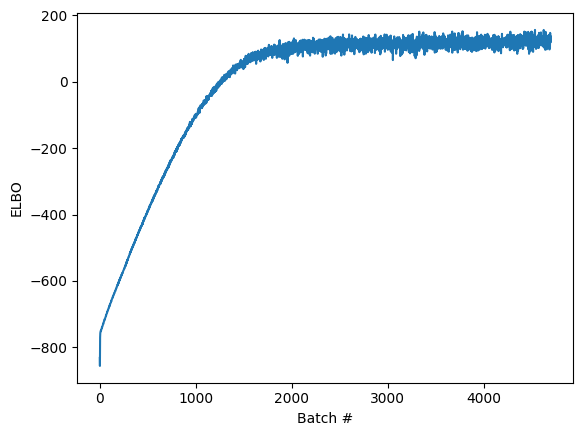

In [96]:
def train_vae(model, dataset, epochs=10, n_samples=1000, batch_size=128):
  """
  VAE trainer.
  """
  optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0)
  model.to(DEVICE)
  model.train()
  elbo_vals = []
  loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
  for epoch in trange(epochs, desc='Epochs'):
    pbar = tqdm(loader, total=len(dataset) // batch_size, desc='Batches', leave=False)
    for im, _ in pbar:
      im = im.to(DEVICE)

      optimizer.zero_grad(set_to_none=True)
      loss = -model.elbo(im, n=n_samples)
      loss.backward()
      optimizer.step()

      elbo_vals.append(-loss.item())

      pbar.set_description('Batches avg ELBO: {:.2f}'.format(np.mean(elbo_vals)))
  model.to('cpu')
  model.eval()
  return elbo_vals


# Train the VAE
elbo_vals = train_vae(vae, train_set, epochs=20, n_samples=10, batch_size=256)
print("Learned sigma_x is {}".format(torch.exp(vae.log_sig_x)))

# Plot ELBO training curve
plt.figure()
plt.plot(elbo_vals)
plt.xlabel('Batch #')
plt.ylabel('ELBO')
plt.show()

In [97]:
# download vae unit test file
!gdown 1bRN-alJ8Ayidu3tprf876FhAcDjGa70a -q -O cpen455_24w2_vae_unit_test.pt

Your implementation is correct.
See below visualizations as a sanity check. (The images should look exactly the same.)


C:\Users\CL\AppData\Local\Temp\ipykernel_17140\878089606.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vae_unit_test_data = torch.load('cpen455_24w2_vae_unit_test.pt'

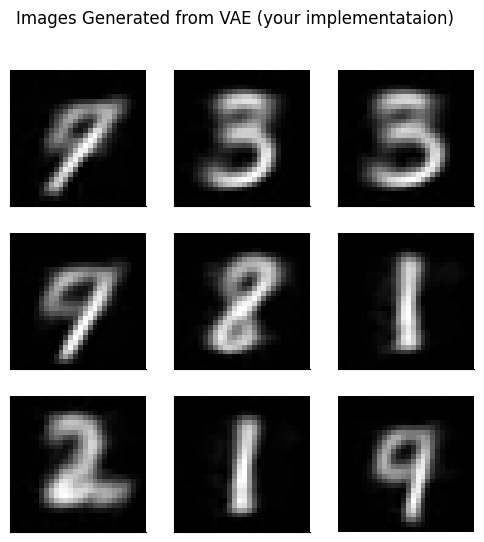

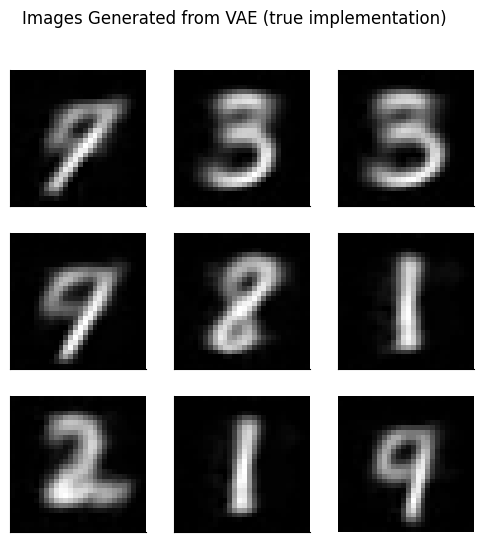

In [138]:
def generate_images(vae, K=2, n_images=9):
  """
  ### Fill in this function ###
  Generate new images from the given VAE. Sample z from a unit gaussian, pass through autoencoder.decode()
  @param vae:       VAE model
  @param K:         int: latent dimensionality
  @param n_images:  int: number of images to generate
  """
  # Init
  output_shape = (n_images,) + data_shape   # [X, C, H, W] = [X, 1, 28, 28] for MNIST
  samples_z = torch.randn(n_images, 1, K)   # [X, 1, K]

  with torch.no_grad():
    ### START CODE HERE ###


    # Use VAE decoder to get
    samples_x = vae.decode(samples_z)  
    # Match to output shape 
    samples_x = samples_x.view(output_shape)  
    

    ### END CODE HERE ###
    return samples_x


def unit_test_generate_images(vae=vae):
  vae_unit_test_data = torch.load('cpen455_24w2_vae_unit_test.pt')
  vae.load_state_dict(vae_unit_test_data['model'])
  vae.eval()
  vae = vae.to('cpu')
  img_samples = vae_unit_test_data['samples']
  images = generate_images(vae, K_VAE, n_images=9)

  error = torch.abs(images - img_samples).mean()
  if error < 1e-5:
    print("Your implementation is correct.")
  else:
    print("Your implementation is incorrect.")

  print("See below visualizations as a sanity check. (The images should look exactly the same.)")

  plot_images(images, plt_title='Images Generated from VAE (your implementataion)')
  plot_images(img_samples, plt_title='Images Generated from VAE (true implementation)')


set_seed(seed=SEED)
unit_test_generate_images()
